In [1292]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torch.optim as optim

from sklearn.datasets import make_gaussian_quantiles
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt
import pandas as pd

import copy
import time

import pennylane as qml
from pennylane.optimize import NesterovMomentumOptimizer
from pennylane import numpy as np

In [1293]:

dev = qml.device("default.qubit")

# Parameter
# --- CONFIGURATION ---
n_samples = 100
n_features_original = 28
n_components = 5
n_qubits = 5
n_clusters_per_class = 1
evolution_time = 2
seed = 42
#np.random.seed(seed)
#torch.manual_seed(seed)# We create our device (ideal simulator -> zero noise, infinite shots)

In [1294]:
data = np.loadtxt("data/iris_classes1and2_scaled.txt")
X = data
Y = data[:,4]
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2)

In [1295]:
def normalize_to_angles(X):
    scaler = MinMaxScaler(feature_range=(-1, 1))
    X = scaler.fit_transform(X)
    X = (-X+1)/2 * np.pi
    return X

def angle_encoder(x):
    for i in range(n_qubits):
        qml.RY(x[i], wires=i)

def hebbian_weights(patterns):
    W = np.sum([np.outer(p, p) for p in patterns], axis=0)
    np.fill_diagonal(W, 0)
    return W

def build_hamiltonian(W, gamma=1.0):
    H = 0
    for i in range(n_qubits):
        for j in range(n_qubits):
            if i != j:
                H += W[i, j] * qml.PauliY(i) @ qml.PauliY(j)
    #for i in range(n_qubits):
    #    H += gamma * qml.PauliX(i)
    return -H  # negative for energy minima

@qml.qnode(dev)
def evolve_and_measure(x, H, time=3.0, steps=1):
    angle_encoder(x)
    qml.ApproxTimeEvolution(H, time, steps)
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

In [1296]:

X_proto_0 = np.sum(X_train[X_train[:,4]==-1], axis=0)/50
X_proto_0[4] = np.sign(X_proto_0[4])
X_proto_1 = np.sum(X_train[X_train[:,4]==1], axis=0)/50
X_proto_1[4] = np.sign(X_proto_1[4])
X_enc = [X_proto_0, X_proto_1]


X_enc = normalize_to_angles(X_enc)
W = hebbian_weights(X_enc)/X_enc.shape[0]
H = build_hamiltonian(W)

print(W)

[[0.00000000e+00 0.00000000e+00 4.93480220e+00 4.93480220e+00
  4.93480220e+00]
 [0.00000000e+00 0.00000000e+00 1.09574621e-15 1.09574621e-15
  1.09574621e-15]
 [4.93480220e+00 1.09574621e-15 0.00000000e+00 4.93480220e+00
  4.93480220e+00]
 [4.93480220e+00 1.09574621e-15 4.93480220e+00 0.00000000e+00
  4.93480220e+00]
 [4.93480220e+00 1.09574621e-15 4.93480220e+00 4.93480220e+00
  0.00000000e+00]]


In [1297]:
X_val_encoded = normalize_to_angles(X_val.copy())
Y_val = X_val[:, 4]  # true labels
X_val_encoded[:, 4] = np.pi/2  # erase class info for testing
idx = 4
print("True label:", Y_val[idx])
print("Input:", -X_val_encoded[idx]/np.pi*2+1)

z = evolve_and_measure(X_val_encoded[idx], H, time=10, steps=10)
print("Output expectation:", [float(z[i]) for i in range(5)])

True label: -1.0
Input: [-0.66666667  1.         -0.78947368 -0.88235294  0.        ]
Output expectation: [0.5579632566945276, 1.0000000000000981, 0.6093715797608157, 0.6333103735133176, -3.3306690738754696e-16]


(<Figure size 500x600 with 1 Axes>, <Axes: >)


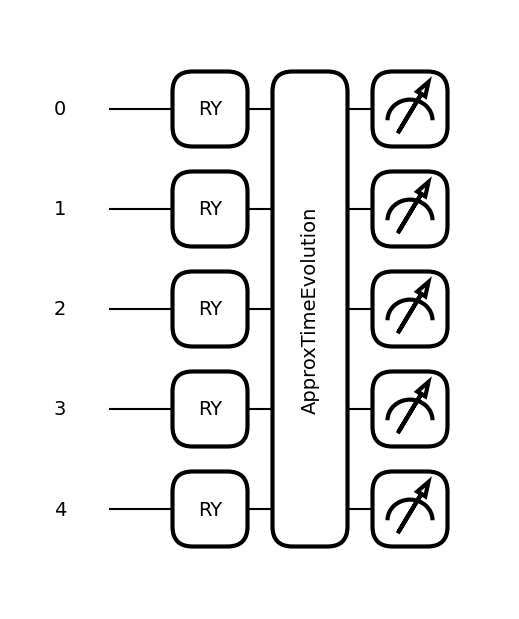

In [1298]:
print(qml.draw_mpl(evolve_and_measure)(X_val_encoded[idx], H, time=1, steps=2))

In [1299]:
X_val_encoded = normalize_to_angles(X_val.copy())
Y_val = X_val[:, 4]  # true labels
X_val_encoded[:, 4] = 0  # erase class info for testing

print(Y_val)

correct = 0
for i in range(len(X_val_encoded)):
    z = evolve_and_measure(X_val_encoded[i], H, time=3.0)

    # Simple thresholding: is qubit 4 closer to +1 or -1?
    pred = 1 if z[4] > 0 else -1

    if pred == Y_val[i]:
        correct += 1

print(f"Validation accuracy: {correct / len(X_val_encoded):.4f}")


[ 1. -1.  1. -1. -1. -1.  1.  1.  1.  1. -1.  1.  1. -1.  1.  1.  1. -1.
  1. -1.]
Validation accuracy: 0.4000
